# SASRec Size-Match Sweep Comparison

This notebook compares four datasets across three headline models:

- `RPG`
- `SASRec Modernized` baseline
- `SASRec Size-Matched` using the **best completed tuned run**

The tuned `SASRec Size-Matched` model is selected per dataset from all completed sweep families:

- original single size-matched run
- `lr_grid`
- `lr_depth_grid`

The notebook also shows:

- which tuned run was chosen for each dataset
- all completed sweep results
- parameter/performance comparisons
- LR and depth sweep plots

In [1]:
from __future__ import annotations

from collections import OrderedDict
from pathlib import Path
import json
import math
import re

import matplotlib.pyplot as plt
import yaml

try:
    import pandas as pd
except ImportError:
    pd = None

ROOT = Path.cwd().resolve()
while ROOT.name not in {"RPG-uva", "RPG"} and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if ROOT.name not in {"RPG-uva", "RPG"}:
    raise RuntimeError("Could not find repo root from the current notebook working directory.")

DATASETS = OrderedDict(
    [
        (
            "Sports_and_Outdoors",
            {
                "slug": "sports_and_outdoors",
                "label": "Sports",
                "prefix": "sports",
                "hidden_size": 326,
            },
        ),
        (
            "Beauty",
            {
                "slug": "beauty",
                "label": "Beauty",
                "prefix": "beauty",
                "hidden_size": 540,
            },
        ),
        (
            "Toys_and_Games",
            {
                "slug": "toys_and_games",
                "label": "Toys",
                "prefix": "toys",
                "hidden_size": 396,
            },
        ),
        (
            "CDs_and_Vinyl",
            {
                "slug": "cds_and_vinyl",
                "label": "CDs",
                "prefix": "cds",
                "hidden_size": 328,
            },
        ),
    ]
)

DATASET_ORDER = [meta["label"] for meta in DATASETS.values()]
HEADLINE_MODEL_ORDER = ["RPG", "SASRec Modernized", "SASRec Size-Matched (Chosen)"]
SWEEP_ORDER = ["single", "lr_grid", "lr_depth_grid"]
SWEEP_LABELS = {
    "single": "Single Run",
    "lr_grid": "LR Grid",
    "lr_depth_grid": "LR+Depth Grid",
}
MODEL_COLORS = {
    "RPG": "#1f77b4",
    "SASRec Modernized": "#ff7f0e",
    "SASRec Size-Matched (Chosen)": "#2ca02c",
}
SWEEP_COLORS = {
    "single": "#9467bd",
    "lr_grid": "#2ca02c",
    "lr_depth_grid": "#8c564b",
}

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
def read_text(path: Path) -> str:
    return path.read_text(encoding="utf-8", errors="ignore")


def parse_ordered_dict_blob(blob: str) -> dict[str, float | int]:
    pairs = re.findall(r"\('([^']+)',\s*'?(.*?)'?\)", blob)
    out: dict[str, float | int] = {}
    for key, value in pairs:
        if key == "Epoch":
            out[key] = int(value)
        else:
            out[key] = float(value)
    return out


def parse_json_header(text: str) -> dict[str, object]:
    match = re.search(r"\{\n(.*?)\n\}", text, re.S)
    if not match:
        return {}
    try:
        return json.loads("{" + match.group(1) + "\n}")
    except json.JSONDecodeError:
        return {}


def parse_sasrec_output(path: Path) -> dict[str, object] | None:
    text = read_text(path)
    if "Loaded best checkpoint for test:" not in text:
        return None
    header = parse_json_header(text)
    run_id = str(header.get("run_id", path.stem))
    checkpoint_match = re.search(r"Loaded best checkpoint for test:\s*(.+)", text)
    metrics_match = re.search(r"Loaded best checkpoint for test:.*?OrderedDict\(\[(.*?)\]\)", text, re.S)
    if metrics_match is None:
        return None
    metrics = parse_ordered_dict_blob(metrics_match.group(1))
    return {
        "run_id": run_id,
        "lr": float(header.get("lr")) if "lr" in header else math.nan,
        "epochs": int(header.get("epochs")) if "epochs" in header else math.nan,
        "hidden_size": int(header.get("hidden_size")) if "hidden_size" in header else math.nan,
        "num_hidden_layers": int(header.get("num_hidden_layers")) if "num_hidden_layers" in header else math.nan,
        "ndcg@5": float(metrics["NDCG@5"]),
        "ndcg@10": float(metrics["NDCG@10"]),
        "ndcg@20": float(metrics["NDCG@20"]),
        "recall@5": float(metrics["RECALL@5"]),
        "recall@10": float(metrics["RECALL@10"]),
        "recall@20": float(metrics["RECALL@20"]),
        "checkpoint_path": checkpoint_match.group(1).strip() if checkpoint_match else None,
        "output_path": str(path),
    }


def parse_rpg_test_metrics(path: Path) -> dict[str, float] | None:
    text = read_text(path)
    matches = re.findall(r"Test Results: OrderedDict\(\[(.*?)\]\)", text, re.S)
    if not matches:
        return None
    metrics = parse_ordered_dict_blob(matches[-1])
    return {
        "ndcg@5": float(metrics["ndcg@5"]),
        "ndcg@10": float(metrics["ndcg@10"]),
        "recall@5": float(metrics["recall@5"]),
        "recall@10": float(metrics["recall@10"]),
    }


def pick_rpg_log(slug: str) -> Path | None:
    log_dir = ROOT / "artifacts" / "rpg" / "logs" / "AmazonReviews2014" / "RPG"
    eval_logs = sorted(log_dir.glob(f"rpg_repro_{slug}-scripts|rpg_eval.py*"))
    if eval_logs:
        return eval_logs[-1]
    train_logs = sorted(log_dir.glob(f"rpg_repro_{slug}-scripts|rpg.py*"))
    return train_logs[-1] if train_logs else None


def sasrec_param_count(n_items: int, hidden_size: int, num_hidden_layers: int) -> int:
    return 12 * num_hidden_layers * hidden_size * hidden_size + (13 * num_hidden_layers + n_items + 54) * hidden_size


def rpg_param_count(n_codebook: int, embd: int = 448, n_layer: int = 2, n_inner: int = 1024, codebook_size: int = 256, n_positions: int = 50) -> int:
    vocab = n_codebook * codebook_size + 2
    return (
        vocab * embd
        + n_positions * embd
        + n_layer * (4 * embd * embd + 2 * embd * n_inner + 9 * embd + n_inner)
        + 2 * embd
        + n_codebook * (embd * embd + embd)
    )

In [3]:
def collect_sweep_rows() -> tuple[list[dict[str, object]], list[str]]:
    rows: list[dict[str, object]] = []
    issues: list[str] = []
    sweep_dirs = {
        "single": ROOT / "output" / "reproduction" / "sasrec_modernized" / "ablation_size",
        "lr_grid": ROOT / "output" / "reproduction" / "sasrec_modernized" / "ablation_size" / "lr_grid",
        "lr_depth_grid": ROOT / "output" / "reproduction" / "sasrec_modernized" / "ablation_size" / "lr_depth_grid",
    }

    for raw_name, meta in DATASETS.items():
        label = meta["label"]
        n_items = int(json.loads((ROOT / "artifacts" / "sasrec" / "data" / raw_name / "summary.json").read_text(encoding="utf-8"))["n_items"])
        for sweep_kind, sweep_dir in sweep_dirs.items():
            pattern = f"*{meta['prefix']}*.out"
            for path in sorted(sweep_dir.glob(pattern)):
                parsed = parse_sasrec_output(path)
                if parsed is None:
                    continue
                parsed["dataset"] = label
                parsed["raw_dataset"] = raw_name
                parsed["sweep_kind"] = sweep_kind
                parsed["params"] = sasrec_param_count(n_items, int(parsed["hidden_size"]), int(parsed["num_hidden_layers"]))
                parsed["params_m"] = parsed["params"] / 1_000_000
                rows.append(parsed)
        if not any(row["dataset"] == label for row in rows):
            issues.append(f"No completed tuned SASRec outputs found for {label}.")

    return rows, issues


sweep_rows, sweep_issues = collect_sweep_rows()
for issue in sweep_issues:
    print(f"- {issue}")

if pd is not None:
    sweep_df = pd.DataFrame(sweep_rows)
    sweep_df["dataset"] = pd.Categorical(sweep_df["dataset"], categories=DATASET_ORDER, ordered=True)
    sweep_df["sweep_kind"] = pd.Categorical(sweep_df["sweep_kind"], categories=SWEEP_ORDER, ordered=True)
    sweep_df = sweep_df.sort_values(["dataset", "sweep_kind", "lr", "num_hidden_layers", "run_id"]).reset_index(drop=True)
    display(
        sweep_df[
            [
                "dataset",
                "sweep_kind",
                "run_id",
                "lr",
                "num_hidden_layers",
                "hidden_size",
                "params_m",
                "ndcg@10",
                "recall@10",
            ]
        ].round({"lr": 6, "params_m": 3, "ndcg@10": 4, "recall@10": 4})
    )
else:
    sweep_df = sweep_rows
    for row in sweep_rows:
        print(row)

,dataset,sweep_kind,run_id,lr,num_hidden_layers,hidden_size,params_m,ndcg@10,recall@10
0,Sports,lr_grid,sasrec_modernized_sports_and_outdoors_size_mat...,0.0003,2,326,8.561,0.0226,0.0418
1,Sports,lr_grid,sasrec_modernized_sports_and_outdoors_size_mat...,0.0005,2,326,8.561,0.0212,0.0396
2,Sports,lr_grid,sasrec_modernized_sports_and_outdoors_size_mat...,0.0010,2,326,8.561,0.0180,0.0338
3,Sports,lr_depth_grid,sasrec_modernized_sports_and_outdoors_size_mat...,0.0003,1,326,7.282,0.0210,0.0398
4,Sports,lr_depth_grid,sasrec_modernized_sports_and_outdoors_size_mat...,0.0003,2,326,8.561,0.0226,0.0418
5,Sports,lr_depth_grid,sasrec_modernized_sports_and_outdoors_size_mat...,0.0003,3,326,9.841,0.0224,0.0416
6,Sports,lr_depth_grid,sasrec_modernized_sports_and_outdoors_size_mat...,0.0005,1,326,7.282,0.0200,0.0384
7,Sports,lr_depth_grid,sasrec_modernized_sports_and_outdoors_size_mat...,0.0005,2,326,8.561,0.0212,0.0396
8,Sports,lr_depth_grid,sasrec_modernized_sports_and_outdoors_size_mat...,0.0005,3,326,9.841,0.0217,0.0397
9,Sports,lr_depth_grid,sasrec_modernized_sports_and_outdoors_size_mat...,0.0010,1,326,7.282,0.0182,0.0354


In [4]:
def choose_best_tuned_runs() -> tuple[list[dict[str, object]], list[str]]:
    chosen: list[dict[str, object]] = []
    issues: list[str] = []
    grouped = sweep_rows if pd is None else sweep_df.to_dict("records")
    for label in DATASET_ORDER:
        candidates = [row for row in grouped if row["dataset"] == label]
        if not candidates:
            issues.append(f"No tuned SASRec candidates found for {label}.")
            continue
        best = max(candidates, key=lambda row: float(row["ndcg@10"]))
        chosen.append(best)
    return chosen, issues


chosen_rows, chosen_issues = choose_best_tuned_runs()
for issue in chosen_issues:
    print(f"- {issue}")

if pd is not None:
    chosen_df = pd.DataFrame(chosen_rows)
    chosen_df["dataset"] = pd.Categorical(chosen_df["dataset"], categories=DATASET_ORDER, ordered=True)
    chosen_df = chosen_df.sort_values("dataset").reset_index(drop=True)
    chosen_df["sweep_label"] = chosen_df["sweep_kind"].map(SWEEP_LABELS)
    display(
        chosen_df[
            [
                "dataset",
                "sweep_label",
                "run_id",
                "lr",
                "num_hidden_layers",
                "hidden_size",
                "params_m",
                "ndcg@10",
                "recall@10",
            ]
        ].round({"lr": 6, "params_m": 3, "ndcg@10": 4, "recall@10": 4})
    )
else:
    chosen_df = chosen_rows
    for row in chosen_rows:
        print(row)

,dataset,sweep_label,run_id,lr,num_hidden_layers,hidden_size,params_m,ndcg@10,recall@10
0,Sports,LR Grid,sasrec_modernized_sports_and_outdoors_size_mat...,0.0003,2,326,8.561,0.0226,0.0418
1,Beauty,LR+Depth Grid,sasrec_modernized_beauty_size_match_e300_lr0p0...,0.0003,3,540,17.082,0.0432,0.0741
2,Toys,LR Grid,sasrec_modernized_toys_and_games_size_match_e3...,0.0003,2,396,8.517,0.0501,0.0818
3,CDs,LR Grid,sasrec_modernized_cds_and_vinyl_size_match_e30...,0.0003,2,328,23.746,0.0340,0.0638


In [5]:
def build_headline_rows() -> tuple[list[dict[str, object]], list[str]]:
    rows: list[dict[str, object]] = []
    issues: list[str] = []
    chosen_lookup = {row['dataset']: row for row in (chosen_rows if pd is None else chosen_df.to_dict('records'))}

    for raw_name, meta in DATASETS.items():
        label = meta["label"]
        n_items = int(json.loads((ROOT / "artifacts" / "sasrec" / "data" / raw_name / "summary.json").read_text(encoding="utf-8"))["n_items"])

        base_dir = ROOT / "output" / "reproduction" / "sasrec_modernized" / meta["slug"]
        base_candidates = sorted(base_dir.glob("*train*.out"))
        base_output = None
        for path in base_candidates:
            if parse_sasrec_output(path) is not None:
                base_output = path
        if base_output is None:
            issues.append(f"Missing baseline SASRec Modernized output for {label}.")
            continue
        base_parsed = parse_sasrec_output(base_output)

        rpg_log = pick_rpg_log(meta["slug"])
        if rpg_log is None:
            issues.append(f"Missing RPG log for {label}.")
            continue
        rpg_metrics = parse_rpg_test_metrics(rpg_log)
        rpg_preset = yaml.safe_load((ROOT / "configs" / "rpg" / "repro" / f"{meta['slug']}.yaml").read_text(encoding="utf-8"))
        chosen = chosen_lookup.get(label)
        if chosen is None:
            issues.append(f"Missing chosen tuned SASRec config for {label}.")
            continue

        rows.append(
            {
                "dataset": label,
                "model": "RPG",
                "params": rpg_param_count(int(rpg_preset["n_codebook"])),
                "params_m": rpg_param_count(int(rpg_preset["n_codebook"])) / 1_000_000,
                "lr": float(rpg_preset["lr"]),
                "num_hidden_layers": math.nan,
                "hidden_size": math.nan,
                "ndcg@10": float(rpg_metrics["ndcg@10"]),
                "recall@10": float(rpg_metrics["recall@10"]),
                "source": str(rpg_log),
            }
        )
        rows.append(
            {
                "dataset": label,
                "model": "SASRec Modernized",
                "params": sasrec_param_count(n_items, int(base_parsed["hidden_size"]), int(base_parsed["num_hidden_layers"])),
                "params_m": sasrec_param_count(n_items, int(base_parsed["hidden_size"]), int(base_parsed["num_hidden_layers"])) / 1_000_000,
                "lr": float(base_parsed["lr"]),
                "num_hidden_layers": int(base_parsed["num_hidden_layers"]),
                "hidden_size": int(base_parsed["hidden_size"]),
                "ndcg@10": float(base_parsed["ndcg@10"]),
                "recall@10": float(base_parsed["recall@10"]),
                "source": str(base_output),
            }
        )
        rows.append(
            {
                "dataset": label,
                "model": "SASRec Size-Matched (Chosen)",
                "params": int(chosen["params"]),
                "params_m": float(chosen["params_m"]),
                "lr": float(chosen["lr"]),
                "num_hidden_layers": int(chosen["num_hidden_layers"]),
                "hidden_size": int(chosen["hidden_size"]),
                "ndcg@10": float(chosen["ndcg@10"]),
                "recall@10": float(chosen["recall@10"]),
                "source": str(chosen["output_path"]),
            }
        )

    return rows, issues


headline_rows, headline_issues = build_headline_rows()
for issue in headline_issues:
    print(f"- {issue}")

if pd is not None:
    headline_df = pd.DataFrame(headline_rows)
    headline_df["dataset"] = pd.Categorical(headline_df["dataset"], categories=DATASET_ORDER, ordered=True)
    headline_df["model"] = pd.Categorical(headline_df["model"], categories=HEADLINE_MODEL_ORDER, ordered=True)
    headline_df = headline_df.sort_values(["dataset", "model"]).reset_index(drop=True)
    display(
        headline_df[
            [
                "dataset",
                "model",
                "params_m",
                "lr",
                "num_hidden_layers",
                "hidden_size",
                "ndcg@10",
                "recall@10",
            ]
        ].round({"params_m": 3, "lr": 6, "ndcg@10": 4, "recall@10": 4})
    )
else:
    headline_df = headline_rows
    for row in headline_rows:
        print(row)

,dataset,model,params_m,lr,num_hidden_layers,hidden_size,ndcg@10,recall@10
0,Sports,RPG,8.528,0.0030,NaN,NaN,0.0251,0.0434
1,Sports,SASRec Modernized,1.278,0.0010,2.0,64.0,0.0166,0.0312
2,Sports,SASRec Size-Matched (Chosen),8.561,0.0003,2.0,326.0,0.0226,0.0418
3,Beauty,RPG,13.582,0.0100,NaN,NaN,0.0454,0.0783
4,Beauty,SASRec Modernized,0.878,0.0010,2.0,64.0,0.0322,0.0590
5,Beauty,SASRec Size-Matched (Chosen),17.082,0.0003,3.0,540.0,0.0432,0.0741
6,Toys,RPG,8.528,0.0030,NaN,NaN,0.0478,0.0852
7,Toys,SASRec Modernized,0.867,0.0010,2.0,64.0,0.0372,0.0668
8,Toys,SASRec Size-Matched (Chosen),8.517,0.0003,2.0,396.0,0.0501,0.0818
9,CDs,RPG,23.689,0.0010,NaN,NaN,0.0404,0.0713


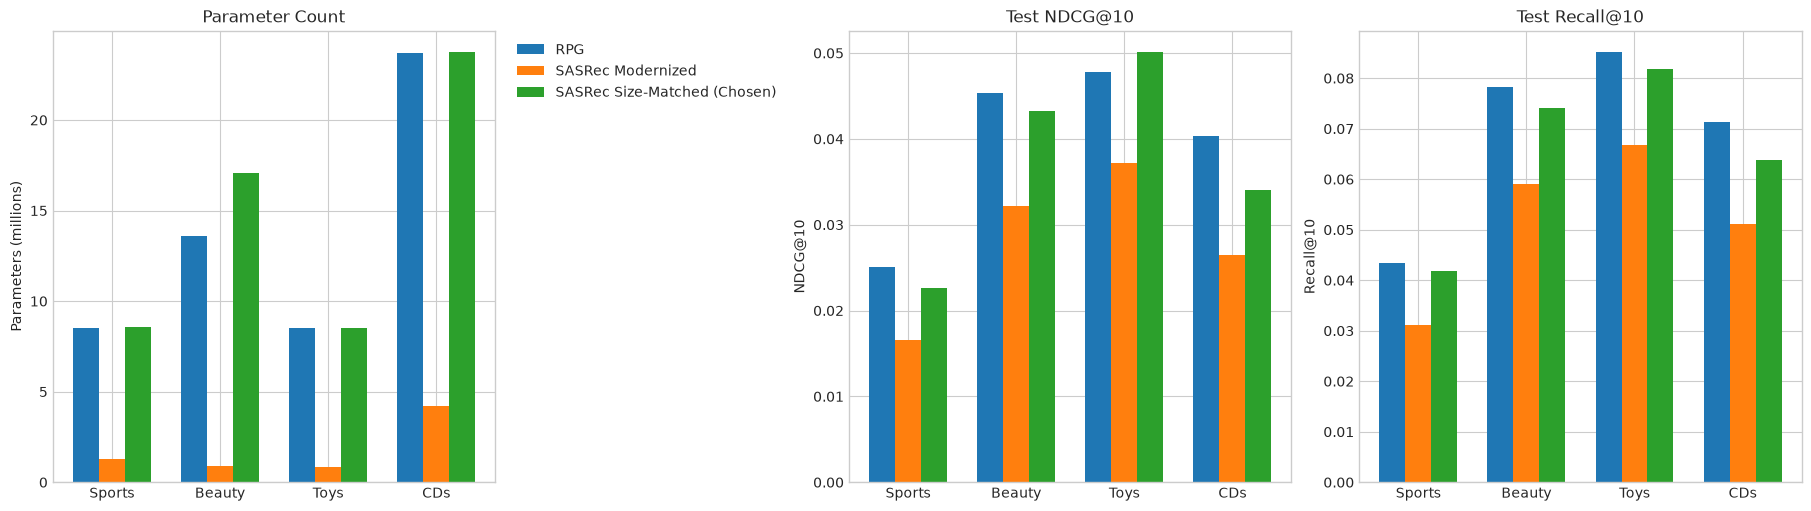

In [6]:
if pd is None:
    raise RuntimeError("pandas is required for the plotting cells in this notebook.")

x = list(range(len(DATASET_ORDER)))
bar_width = 0.24
offsets = {
    "RPG": -bar_width,
    "SASRec Modernized": 0.0,
    "SASRec Size-Matched (Chosen)": bar_width,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
for model in HEADLINE_MODEL_ORDER:
    subset = headline_df[headline_df["model"] == model].set_index("dataset").reindex(DATASET_ORDER)
    positions = [value + offsets[model] for value in x]
    axes[0].bar(positions, subset["params_m"], width=bar_width, label=model, color=MODEL_COLORS[model])
    axes[1].bar(positions, subset["ndcg@10"], width=bar_width, label=model, color=MODEL_COLORS[model])
    axes[2].bar(positions, subset["recall@10"], width=bar_width, label=model, color=MODEL_COLORS[model])

for ax, title, ylabel in [
    (axes[0], "Parameter Count", "Parameters (millions)"),
    (axes[1], "Test NDCG@10", "NDCG@10"),
    (axes[2], "Test Recall@10", "Recall@10"),
]:
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(DATASET_ORDER)
    ax.set_ylabel(ylabel)

axes[0].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.show()

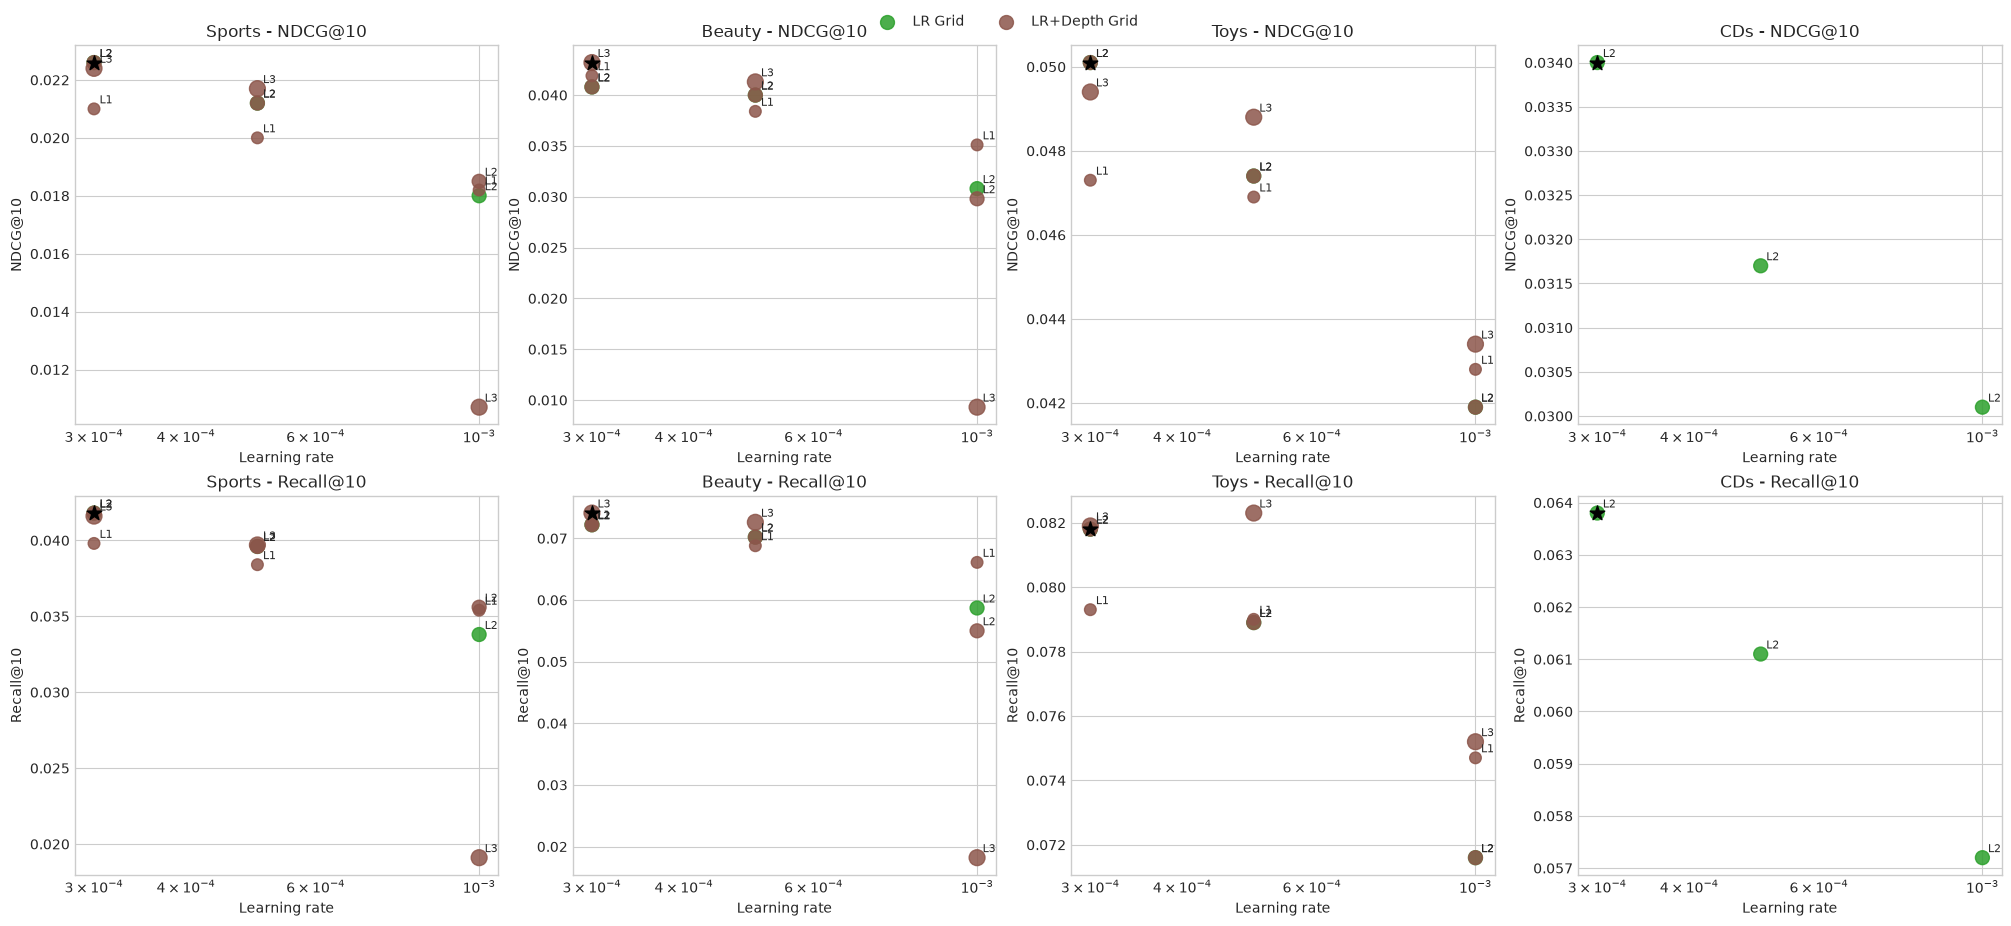

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9), constrained_layout=True)

for col, dataset_label in enumerate(DATASET_ORDER):
    subset = sweep_df[sweep_df["dataset"] == dataset_label].copy()
    if subset.empty:
        axes[0, col].set_visible(False)
        axes[1, col].set_visible(False)
        continue
    subset = subset.sort_values(["sweep_kind", "lr", "num_hidden_layers"])
    chosen_row = chosen_df[chosen_df["dataset"] == dataset_label].iloc[0]
    for row_idx, metric in enumerate(["ndcg@10", "recall@10"]):
        ax = axes[row_idx, col]
        for sweep_kind in SWEEP_ORDER:
            sweep_subset = subset[subset["sweep_kind"] == sweep_kind]
            if sweep_subset.empty:
                continue
            sizes = 40 + 30 * sweep_subset["num_hidden_layers"].fillna(2)
            ax.scatter(
                sweep_subset["lr"],
                sweep_subset[metric],
                s=sizes,
                alpha=0.85,
                color=SWEEP_COLORS[sweep_kind],
                label=SWEEP_LABELS[sweep_kind],
            )
            for _, row in sweep_subset.iterrows():
                layer_value = row["num_hidden_layers"]
                layer_text = f"L{int(layer_value)}" if not math.isnan(float(layer_value)) else "L?"
                ax.annotate(layer_text, (row["lr"], row[metric]), xytext=(4, 4), textcoords="offset points", fontsize=8)
        ax.scatter([chosen_row["lr"]], [chosen_row[metric]], color="black", s=120, marker="*", zorder=5)
        ax.set_xscale("log")
        ax.set_title(f"{dataset_label} - {'NDCG@10' if metric == 'ndcg@10' else 'Recall@10'}")
        ax.set_xlabel("Learning rate")
        ax.set_ylabel("NDCG@10" if metric == "ndcg@10" else "Recall@10")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02))
plt.show()

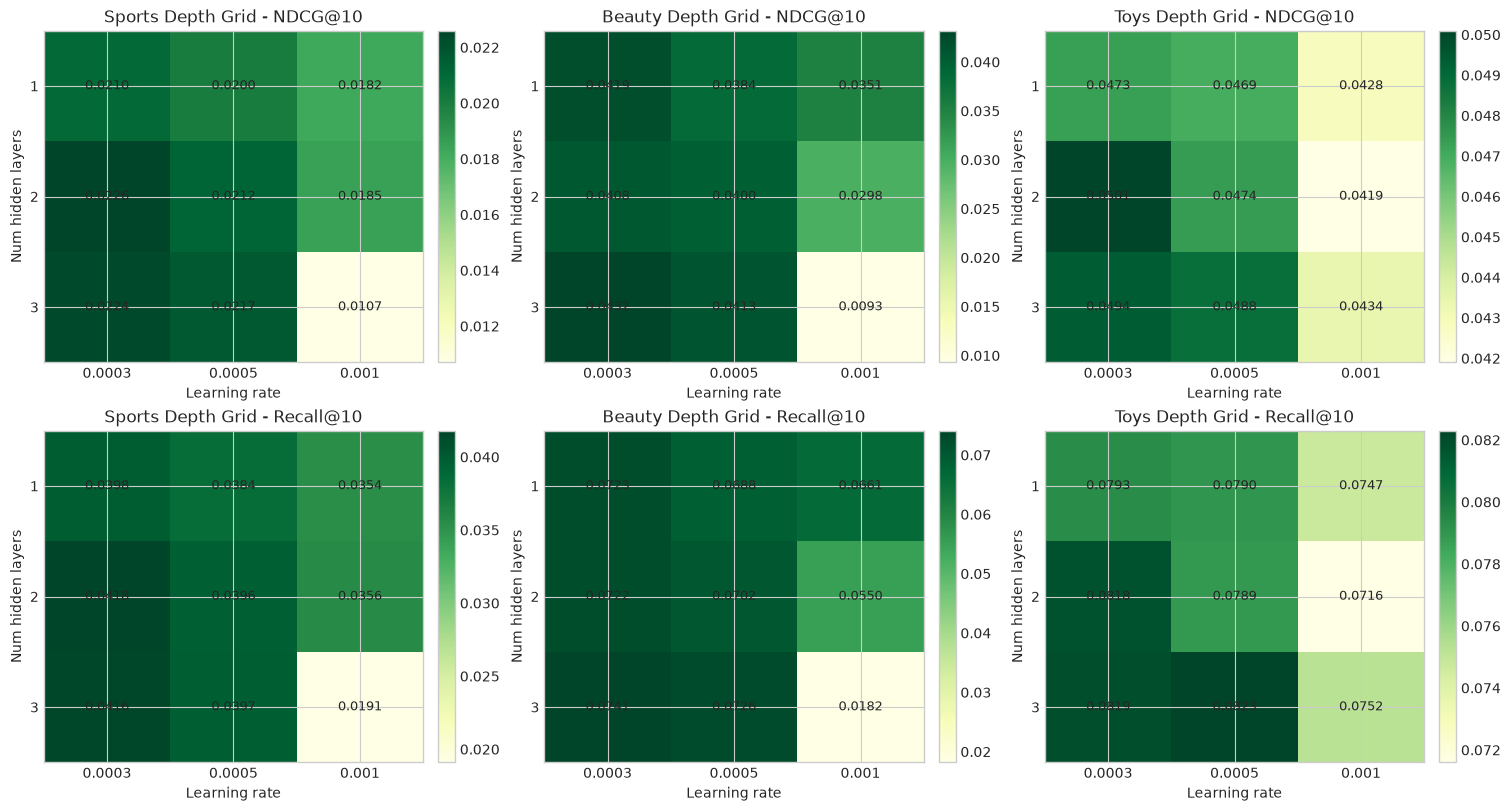

In [8]:
depth_subset = sweep_df[sweep_df["sweep_kind"] == "lr_depth_grid"].copy()
depth_datasets = [label for label in DATASET_ORDER if label in set(depth_subset["dataset"])]
if depth_datasets:
    fig, axes = plt.subplots(2, len(depth_datasets), figsize=(5 * len(depth_datasets), 8), constrained_layout=True)
    if len(depth_datasets) == 1:
        axes = [[axes[0]], [axes[1]]]
    for col, dataset_label in enumerate(depth_datasets):
        for row_idx, metric in enumerate(["ndcg@10", "recall@10"]):
            ax = axes[row_idx][col]
            pivot = depth_subset[depth_subset["dataset"] == dataset_label].pivot(index="num_hidden_layers", columns="lr", values=metric).sort_index()
            im = ax.imshow(pivot.values, aspect="auto", cmap="YlGn")
            ax.set_title(f"{dataset_label} Depth Grid - {'NDCG@10' if metric == 'ndcg@10' else 'Recall@10'}")
            ax.set_xlabel("Learning rate")
            ax.set_ylabel("Num hidden layers")
            ax.set_xticks(range(len(pivot.columns)))
            ax.set_xticklabels([f"{lr:.4g}" for lr in pivot.columns])
            ax.set_yticks(range(len(pivot.index)))
            ax.set_yticklabels([int(v) for v in pivot.index])
            for i in range(pivot.shape[0]):
                for j in range(pivot.shape[1]):
                    ax.text(j, i, f"{pivot.iloc[i, j]:.4f}", ha="center", va="center", fontsize=9)
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.show()

## Performance Comparison: Baseline vs Best Ablation

This section reads the latest completed profiling comparison per dataset from `artifacts/sasrec_modernized/perf/<dataset>/comparison/...`.

It compares the baseline `SASRec Modernized` checkpoint against the chosen best size-ablation checkpoint across candidate-pool sizes.


In [ ]:
def latest_complete_perf_comparison_dir(dataset_slug: str) -> Path | None:
    compare_root = ROOT / "artifacts" / "sasrec_modernized" / "perf" / dataset_slug / "comparison"
    if not compare_root.is_dir():
        return None
    candidates = []
    for path in compare_root.iterdir():
        if not path.is_dir():
            continue
        if (path / "comparison_deltas.csv").is_file() and (path / "checkpoints.json").is_file():
            candidates.append(path)
    if not candidates:
        return None
    return sorted(candidates)[-1]


def collect_perf_comparison_rows() -> tuple[list[dict[str, object]], list[dict[str, object]], list[str]]:
    rows: list[dict[str, object]] = []
    manifests: list[dict[str, object]] = []
    issues: list[str] = []

    for raw_name, meta in DATASETS.items():
        compare_dir = latest_complete_perf_comparison_dir(meta["slug"])
        if compare_dir is None:
            issues.append(f"No completed perf comparison found yet for {meta['label']}.")
            continue

        delta_path = compare_dir / "comparison_deltas.csv"
        checkpoints_path = compare_dir / "checkpoints.json"
        manifest = json.loads(checkpoints_path.read_text(encoding="utf-8"))
        manifests.append(
            {
                "dataset": meta["label"],
                "dataset_slug": meta["slug"],
                "comparison_dir": str(compare_dir),
                "pool_sizes": manifest.get("pool_sizes", ""),
                "baseline_checkpoint": manifest.get("baseline_checkpoint", ""),
                "best_ablation_checkpoint": manifest.get("best_ablation_checkpoint", ""),
                "best_ablation_run_id": manifest.get("best_ablation_run_id", ""),
                "best_ablation_test_ndcg10": manifest.get("best_ablation_test_ndcg10"),
                "best_ablation_test_ndcg20": manifest.get("best_ablation_test_ndcg20"),
            }
        )

        if pd is None:
            continue
        frame = pd.read_csv(delta_path)
        frame["dataset"] = meta["label"]
        frame["dataset_slug"] = meta["slug"]
        frame["best_ablation_run_id"] = manifest.get("best_ablation_run_id", "")
        frame["comparison_dir"] = str(compare_dir)
        rows.extend(frame.to_dict("records"))

    return rows, manifests, issues


perf_rows, perf_manifests, perf_issues = collect_perf_comparison_rows()
for issue in perf_issues:
    print(f"- {issue}")

if pd is not None:
    perf_df = pd.DataFrame(perf_rows)
    perf_manifest_df = pd.DataFrame(perf_manifests)
    if not perf_df.empty:
        perf_df["dataset"] = pd.Categorical(perf_df["dataset"], categories=DATASET_ORDER, ordered=True)
        perf_df = perf_df.sort_values(["dataset", "pool_size"]).reset_index(drop=True)
    if not perf_manifest_df.empty:
        perf_manifest_df["dataset"] = pd.Categorical(perf_manifest_df["dataset"], categories=DATASET_ORDER, ordered=True)
        perf_manifest_df = perf_manifest_df.sort_values("dataset").reset_index(drop=True)
else:
    perf_df = None
    perf_manifest_df = None


In [ ]:
if pd is None:
    raise RuntimeError("pandas is required for the perf comparison tables.")

if perf_manifest_df is None or perf_manifest_df.empty:
    print("No completed perf comparison directories found yet.")
else:
    display(
        perf_manifest_df[
            [
                "dataset",
                "best_ablation_run_id",
                "best_ablation_test_ndcg10",
                "best_ablation_test_ndcg20",
                "pool_sizes",
                "comparison_dir",
            ]
        ]
    )

if perf_df is None or perf_df.empty:
    print("No perf delta rows available yet.")
else:
    display(
        perf_df[
            [
                "dataset",
                "pool_size",
                "baseline_epoch_time_s_median",
                "candidate_epoch_time_s_median",
                "epoch_time_delta_s",
                "baseline_peak_cuda_runtime_delta_allocated_gb_median",
                "candidate_peak_cuda_runtime_delta_allocated_gb_median",
                "peak_cuda_runtime_delta_allocated_gb_delta",
                "baseline_ndcg_at_10_median",
                "candidate_ndcg_at_10_median",
                "ndcg_at_10_delta",
                "best_ablation_run_id",
            ]
        ]
    )


In [ ]:
if pd is None:
    raise RuntimeError("pandas is required for the perf comparison plots.")

if perf_df is None or perf_df.empty:
    print("No completed perf comparison data available for plotting yet.")
else:
    available_datasets = [label for label in DATASET_ORDER if label in set(perf_df["dataset"]) ]
    fig, axes = plt.subplots(2, len(available_datasets), figsize=(5 * len(available_datasets), 8), constrained_layout=True)
    if len(available_datasets) == 1:
        axes = [[axes[0]], [axes[1]]]

    for col, dataset_label in enumerate(available_datasets):
        subset = perf_df[perf_df["dataset"] == dataset_label].sort_values("pool_size")

        ax_time = axes[0][col]
        ax_time.plot(subset["pool_size"], subset["baseline_epoch_time_s_median"], marker="o", label="Baseline")
        ax_time.plot(subset["pool_size"], subset["candidate_epoch_time_s_median"], marker="o", label="Best Ablation")
        ax_time.set_title(f"{dataset_label} Epoch Time")
        ax_time.set_xlabel("Pool size")
        ax_time.set_ylabel("Median epoch time (s)")
        ax_time.grid(True, alpha=0.3)
        ax_time.legend()

        ax_mem = axes[1][col]
        ax_mem.plot(subset["pool_size"], subset["baseline_peak_cuda_runtime_delta_allocated_gb_median"], marker="o", label="Baseline")
        ax_mem.plot(subset["pool_size"], subset["candidate_peak_cuda_runtime_delta_allocated_gb_median"], marker="o", label="Best Ablation")
        ax_mem.set_title(f"{dataset_label} CUDA Runtime Memory")
        ax_mem.set_xlabel("Pool size")
        ax_mem.set_ylabel("Peak runtime delta allocated (GB)")
        ax_mem.grid(True, alpha=0.3)
        ax_mem.legend()

    plt.show()
